# Meeting Notes Taker

Convert speech to text(transcript) and then create meeting-notes from text(transcript)

### STEPS TO RUN THIS NOTEBOOK:

**Packages to install:**

pip install transformers==4.35.2 \
torch==2.1.1 \
gradio==5.9.0 \
langchain==0.3.12 \
langchain-community==0.3.12 \
langchain_ibm==0.3.5 \
ibm-watsonx-ai==1.1.16 \
pydantic==2.10.3


**Install `ffmpeg` on machine**

sudo apt update\
sudo apt install ffmpeg -y



In [ ]:
import torch
from transformers import pipeline

# Initialize the speech-to-text pipeline from Hugging Face Transformers
# This uses the "openai/whisper-tiny.en" model for automatic speech recognition (ASR)
# The `chunk_length_s` parameter specifies the chunk length in seconds for processing
pipe = pipeline(
  "automatic-speech-recognition",
  model="openai/whisper-tiny.en",
  chunk_length_s=30,
)

# Define the path to the audio file that needs to be transcribed
sample = 'khabib-about-discipline.mp3'

# Perform speech recognition on the audio file
# The `batch_size=8` parameter indicates how many chunks are processed at a time
# The result is stored in `prediction` with the key "text" containing the transcribed text
prediction = pipe(sample, batch_size=8)["text"]

# Print the transcribed text to the console
print(prediction)

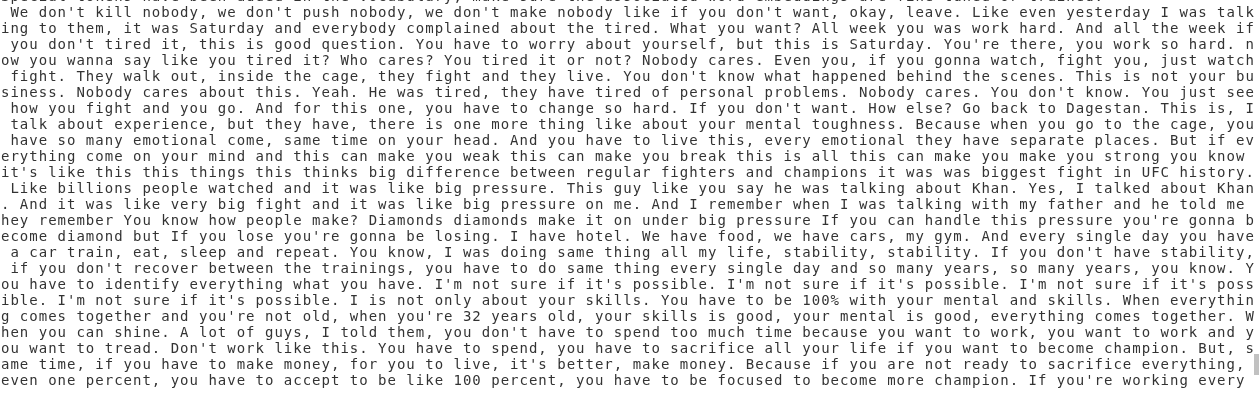

In [ ]:
import torch
from transformers import pipeline
import gradio as gr

# Function to transcribe audio using the OpenAI Whisper model
def transcript_audio(audio_file):
    # Initialize the speech recognition pipeline
    pipe = pipeline(
        "automatic-speech-recognition",
        model="openai/whisper-tiny.en",
        chunk_length_s=30,
        )

    # Transcribe the audio file and return the result
    result = pipe(audio_file, batch_size=8)["text"]
    return result

# Set up Gradio interface
audio_input = gr.Audio(sources="upload", type="filepath")  # Audio input
output_text = gr.Textbox()  # Text output

iface = gr.Interface(fn=transcript_audio, 
                     inputs=audio_input, outputs=output_text, 
                     title="Audio Transcription App",
                     description="Upload the audio file")

iface.launch() # Launch the Gradio app

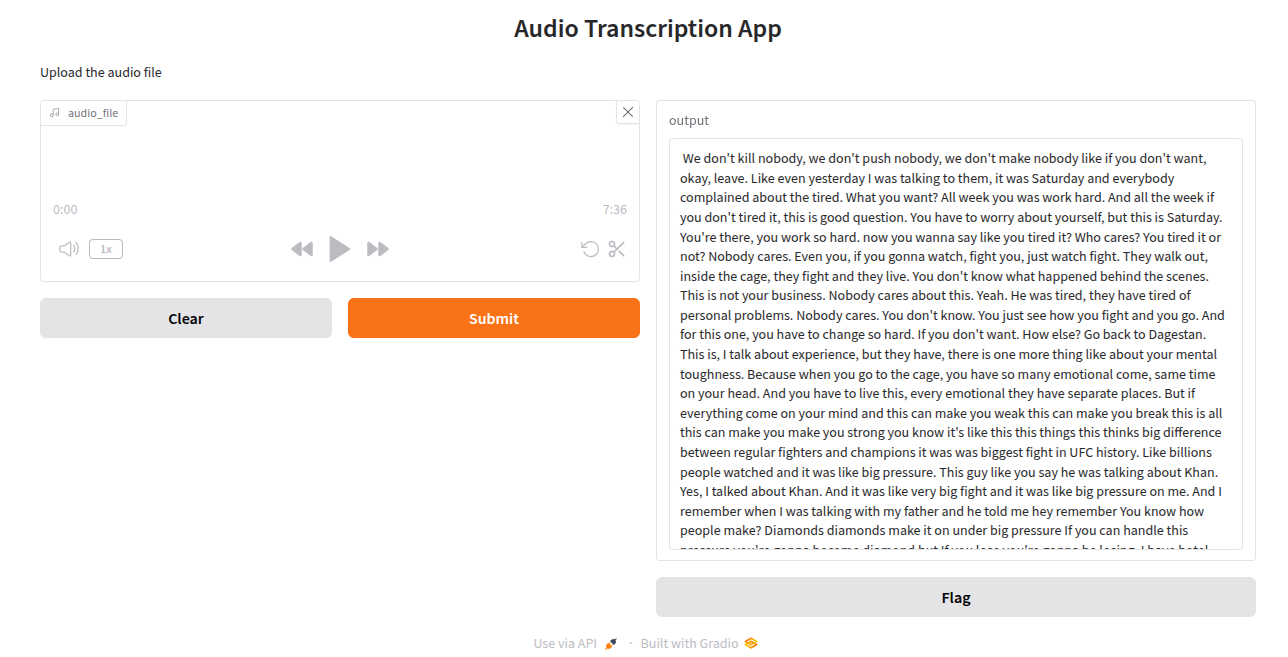

In [ ]:
import torch
import os
import gradio as gr
from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain.prompts import PromptTemplate
from transformers import pipeline  # For Speech-to-Text

#######------------- LLM Initialization-------------#######

# Initialize OpenAI client (expects OPENAI_API_KEY in env)
client = OpenAI()

# Clean OpenAI LLM initialization (no params here)
llm = ChatOpenAI(model="gpt-4o-mini")

#######------------- Helper Functions-------------#######

# Function to remove non-ASCII characters
def remove_non_ascii(text):
    return ''.join(i for i in text if ord(i) < 128)

In [ ]:
# This functions is used to refactor transcript. (means: preprocess transcript)
def product_assistant(ascii_transcript):
    system_prompt = """You are an intelligent assistant specializing in financial products;
    your task is to process transcripts of earnings calls, ensuring that all references to
     financial products and common financial terms are in the correct format. For each
     financial product or common term that is typically abbreviated as an acronym, the full term 
    should be spelled out followed by the acronym in parentheses. For example, '401k' should be
     transformed to '401(k) retirement savings plan', 'HSA' should be transformed to 'Health Savings Account (HSA)' , 'ROA' should be transformed to 'Return on Assets (ROA)', 'VaR' should be transformed to 'Value at Risk (VaR)', and 'PB' should be transformed to 'Price to Book (PB) ratio'. Similarly, transform spoken numbers representing financial products into their numeric representations, followed by the full name of the product in parentheses. For instance, 'five two nine' to '529 (Education Savings Plan)' and 'four zero one k' to '401(k) (Retirement Savings Plan)'. However, be aware that some acronyms can have different meanings based on the context (e.g., 'LTV' can stand for 'Loan to Value' or 'Lifetime Value'). You will need to discern from the context which term is being referred to  and apply the appropriate transformation. In cases where numerical figures or metrics are spelled out but do not represent specific financial products (like 'twenty three percent'), these should be left as is. Your role is to analyze and adjust financial product terminology in the text. Once you've done that, produce the adjusted transcript and a list of the words you've changed"""

    # Concatenate the system prompt and the user transcript
    prompt_input = system_prompt + "\n" + ascii_transcript

    # OpenAI chat call
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "user", "content": prompt_input}
        ]
    )

    return response.choices[0].message.content

In [ ]:
#######------------- Prompt Template and Chain-------------#######

# Define the prompt template
template = """
Generate meeting minutes and a list of tasks based on the provided context.

Context:
{context}

Meeting Minutes:
- Key points discussed
- Decisions made

Task List:
- Actionable items with assignees and deadlines
"""

prompt = ChatPromptTemplate.from_template(template)

# Define the chain
chain = (
     {"context": RunnablePassthrough()}  # Pass the transcript as context
    | prompt
    | llm
    | StrOutputParser()
)

#######------------- Speech2text and Pipeline-------------#######

# Speech-to-text pipeline
def transcript_audio(audio_file):
    pipe = pipeline(
            "automatic-speech-recognition",
            model="openai/whisper-medium",
            chunk_length_s=30,
        )
    raw_transcript = pipe(audio_file, batch_size=8)["text"]
    ascii_transcript = remove_non_ascii(raw_transcript)

    # adjusted_transcript = product_assistant(ascii_transcript)
    # result = chain.invoke({"context": adjusted_transcript})
    
    result = chain.invoke({"context": ascii_transcript})

    # Write the result to a file for downloading
    output_file = "meeting_minutes_and_tasks.txt"
    with open(output_file, "w") as file:
        file.write(result)

    # Return the textual result and the file for download
    return result, output_file


#######------------- Gradio Interface-------------#######

audio_input = gr.Audio(sources="upload", type="filepath", label="Upload your audio file")
output_text = gr.Textbox(label="Meeting Minutes and Tasks")
download_file = gr.File(label="Download the Generated Meeting Minutes and Tasks")

iface = gr.Interface(
    fn=transcript_audio,
    inputs=audio_input,
    outputs=[output_text, download_file],
    title="AI Meeting Assistant",
    description="Upload an audio file of a meeting. This tool will transcribe the audio, fix product-related terminology, and generate meeting minutes along with a list of tasks."
)

iface.launch()

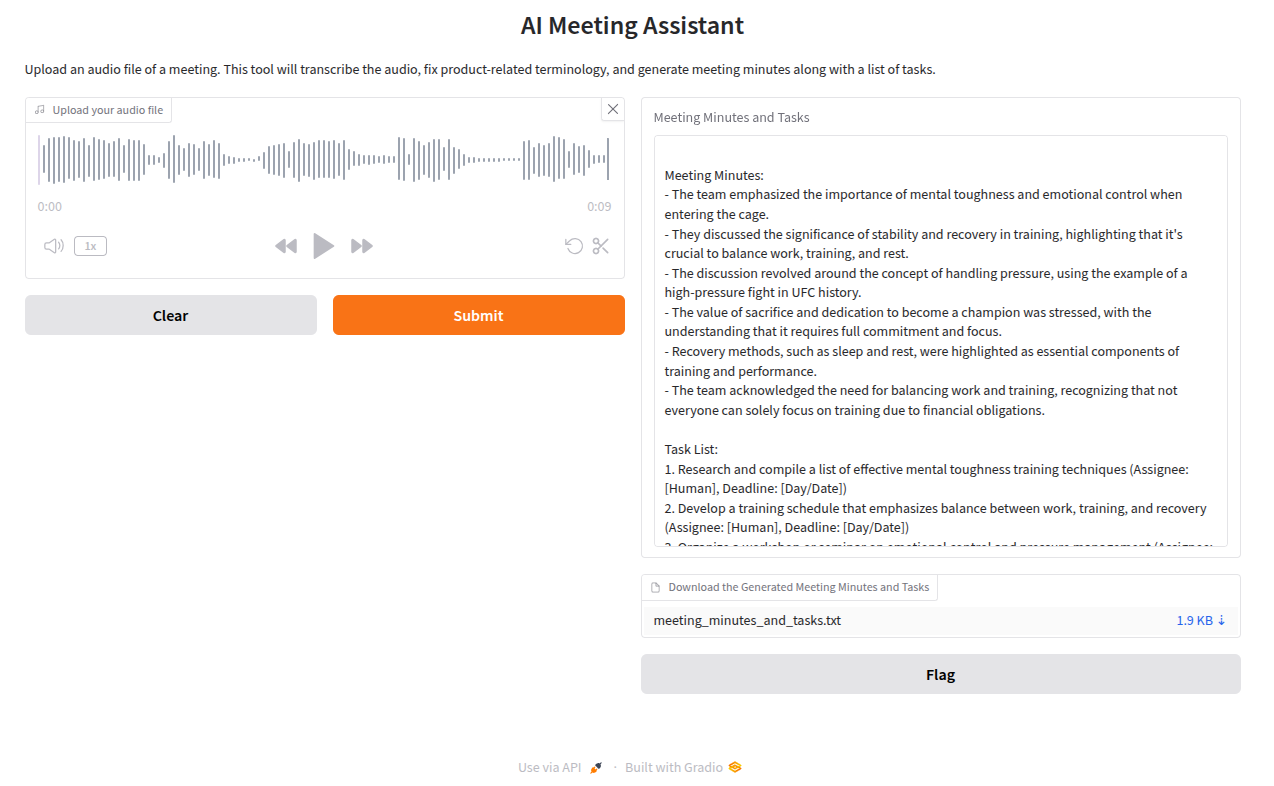